# Data Augmentation for Contrastive Learning (Multi-band Light Curves)

This notebook generates **two stochastic augmented views** of each *object-level* light curve sequence for SimCLR/BYOL-style contrastive learning.

**Input options**
1) Preferred: `light_curves_sequences.npz` produced by the preprocessing notebook (fixed-length sequences per `oid`).
2) Fallback: `light_curves.csv` (will build simple sequences inside this notebook).

**Goal:** create two views *(v1, v2)* for each object so the encoder learns **augmentation-invariant** representations of transient temporal patterns across filters (g/r/i).


In [1]:
# -------------------------
# 1) Imports + paths
# -------------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# Paths (edit if needed)
SEQ_NPZ = "light_curves_sequences.npz"   # produced by preprocessing notebook
CSV_PATH = "light_curves.csv"           # raw observations (fallback)

# Output
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PAIRS = os.path.join(OUT_DIR, "light_curve_pairs.npz")

print("SEQ_NPZ exists:", os.path.exists(SEQ_NPZ))
print("CSV_PATH exists:", os.path.exists(CSV_PATH))


SEQ_NPZ exists: False
CSV_PATH exists: True


## 2) Load sequences

### Expected `.npz` format (from preprocessing)
- `X`: array of shape **(N_objects, T, F)**  
- `time`: optional (T,) or (N,T) time grid  
- `oid`: object ids (N,)
- `feature_names`: names for the F features

If you don’t have the `.npz` yet, run the preprocessing notebook first. This notebook can still work from the CSV, but fixed-length sequences are recommended for contrastive training.


In [2]:
# -------------------------
# 2) Load sequences (preferred) or build from CSV (fallback)
# -------------------------
def load_sequences_from_npz(path: str):
    data = np.load(path, allow_pickle=True)
    X = data["X"]
    oid = data["oid"] if "oid" in data else np.arange(len(X))
    feature_names = data["feature_names"].tolist() if "feature_names" in data else [f"f{i}" for i in range(X.shape[-1])]
    time = data["time"] if "time" in data else None
    return X, oid, feature_names, time

def build_sequences_from_csv(csv_path: str, T: int = 128):
    """Simple fallback: group by oid, sort by mjd, take last/first T rows with padding.
    Features: [mag_used, err_used, fid_norm] (you can extend later).
    """
    df = pd.read_csv(csv_path)

    # Choose magnitude + error consistently with the new dataset
    if "magpsf" in df.columns:
        df["mag_used"] = df["magpsf"]
    else:
        df["mag_used"] = df["mag"]

    if "sigmapsf" in df.columns:
        df["err_used"] = df["sigmapsf"]
    else:
        df["err_used"] = df.get("e_mag", np.nan)

    # Filter id (1=g,2=r,3=i in ZTF)
    df["fid"] = df["fid"].astype(int)
    df = df.sort_values(["oid", "mjd"])

    oids = df["oid"].unique()
    X_list = []
    for oid in oids:
        g = df[df["oid"] == oid]
        # keep last T observations (often denser near event peak)
        g = g.tail(T)
        # pad if needed
        pad = T - len(g)
        mag = g["mag_used"].to_numpy(np.float32)
        err = g["err_used"].to_numpy(np.float32)
        fid = g["fid"].to_numpy(np.float32)

        # Normalize fid to [0,1]
        fid_norm = (fid - 1.0) / 2.0

        # Stack features
        x = np.stack([mag, err, fid_norm], axis=-1)  # (t,3)

        if pad > 0:
            x_pad = np.zeros((pad, x.shape[1]), dtype=np.float32)
            x = np.concatenate([x_pad, x], axis=0)

        X_list.append(x)

    X = np.stack(X_list, axis=0)  # (N,T,F)
    feature_names = ["mag_used", "err_used", "fid_norm"]
    return X, oids, feature_names, None

if os.path.exists(SEQ_NPZ):
    X, oid, feature_names, time = load_sequences_from_npz(SEQ_NPZ)
else:
    X, oid, feature_names, time = build_sequences_from_csv(CSV_PATH, T=128)

print("X shape:", X.shape, "dtype:", X.dtype)
print("Example feature_names:", feature_names[:10])


X shape: (5, 128, 3) dtype: float32
Example feature_names: ['mag_used', 'err_used', 'fid_norm']


## 3) Augmentation design (light curves)

We generate two views by combining:
- **Temporal jitter / warp (lightweight):** small random shift and optional random crop
- **Magnitude offset + scaling:** simulate calibration/brightness variation
- **Noise injection:** add Gaussian noise (optionally scaled by `err_used`)
- **Time-step masking (dropout):** simulate missing observations / cadence gaps
- **Band dropout (optional):** drop a subset of points from a specific filter signal

These are aligned with your proposal’s augmentation plan (temporal jitter, magnitude scaling, noise injection, partial sequence cropping). fileciteturn0file0L53-L56


In [3]:
# -------------------------
# 3) Augmentation functions (operate on sequences: (T,F))
# -------------------------
def _shift_sequence(x, max_shift=5, rng=None):
    """Circular-ish shift with zero padding (not roll)."""
    rng = rng or np.random.default_rng()
    T = x.shape[0]
    s = int(rng.integers(-max_shift, max_shift + 1))
    if s == 0:
        return x
    out = np.zeros_like(x)
    if s > 0:
        out[s:] = x[:T - s]
    else:
        out[:T + s] = x[-s:]
    return out

def _random_crop_and_pad(x, crop_min_frac=0.6, rng=None):
    rng = rng or np.random.default_rng()
    T = x.shape[0]
    crop_len = int(rng.integers(int(T * crop_min_frac), T + 1))
    start = int(rng.integers(0, T - crop_len + 1))
    crop = x[start:start + crop_len]
    # pad back to length T (centered)
    pad_total = T - crop_len
    left = pad_total // 2
    right = pad_total - left
    return np.pad(crop, ((left, right), (0, 0)), mode="constant")

def _magnitude_offset_scale(x, mag_idx=0, offset_std=0.15, scale_std=0.03, rng=None):
    rng = rng or np.random.default_rng()
    out = x.copy()
    offset = float(rng.normal(0.0, offset_std))
    scale = float(1.0 + rng.normal(0.0, scale_std))
    out[:, mag_idx] = out[:, mag_idx] * scale + offset
    return out

def _noise_injection(x, err_idx=1, mag_idx=0, base_std=0.02, use_err=True, rng=None):
    rng = rng or np.random.default_rng()
    out = x.copy()
    if use_err and x.shape[1] > max(err_idx, mag_idx):
        sigma = np.nan_to_num(out[:, err_idx], nan=base_std, posinf=base_std, neginf=base_std)
        sigma = np.clip(sigma, 1e-4, 1.0)
        noise = rng.normal(0.0, sigma, size=out[:, mag_idx].shape).astype(np.float32)
    else:
        noise = rng.normal(0.0, base_std, size=out[:, mag_idx].shape).astype(np.float32)
    out[:, mag_idx] = out[:, mag_idx] + noise
    return out

def _time_mask(x, mask_prob=0.05, rng=None):
    rng = rng or np.random.default_rng()
    out = x.copy()
    T = out.shape[0]
    mask = rng.random(T) < mask_prob
    out[mask] = 0.0
    return out

def _band_dropout(x, fid_norm_idx=2, drop_prob=0.1, rng=None):
    """If fid_norm exists (0=g,0.5=r,1=i), randomly drop one band's points."""
    rng = rng or np.random.default_rng()
    if x.shape[1] <= fid_norm_idx or rng.random() > drop_prob:
        return x
    out = x.copy()
    # choose a band among {0,0.5,1}
    band = float(rng.choice([0.0, 0.5, 1.0]))
    band_mask = np.isclose(out[:, fid_norm_idx], band, atol=1e-3)
    out[band_mask] = 0.0
    return out

def augment_light_curve(x, rng=None):
    rng = rng or np.random.default_rng()

    # Compose augmentations (order matters a bit)
    out = x
    out = _shift_sequence(out, max_shift=5, rng=rng)
    out = _random_crop_and_pad(out, crop_min_frac=0.65, rng=rng)
    out = _magnitude_offset_scale(out, mag_idx=0, offset_std=0.12, scale_std=0.02, rng=rng)
    out = _noise_injection(out, err_idx=1, mag_idx=0, base_std=0.02, use_err=True, rng=rng)
    out = _time_mask(out, mask_prob=0.06, rng=rng)
    out = _band_dropout(out, fid_norm_idx=2, drop_prob=0.12, rng=rng)
    return out.astype(np.float32)

def make_two_views(X, rng=None):
    rng = rng or np.random.default_rng()
    V1 = np.stack([augment_light_curve(x, rng=rng) for x in X], axis=0)
    V2 = np.stack([augment_light_curve(x, rng=rng) for x in X], axis=0)
    return V1, V2

V1, V2 = make_two_views(X, rng=rng)
print("V1/V2 shape:", V1.shape, V2.shape)


V1/V2 shape: (5, 128, 3) (5, 128, 3)


## 4) Sanity checks

We visualize one random object’s sequence before/after augmentation to confirm:
- temporal structure is roughly preserved
- magnitude values are perturbed but not destroyed
- masking/cropping creates realistic missingness patterns


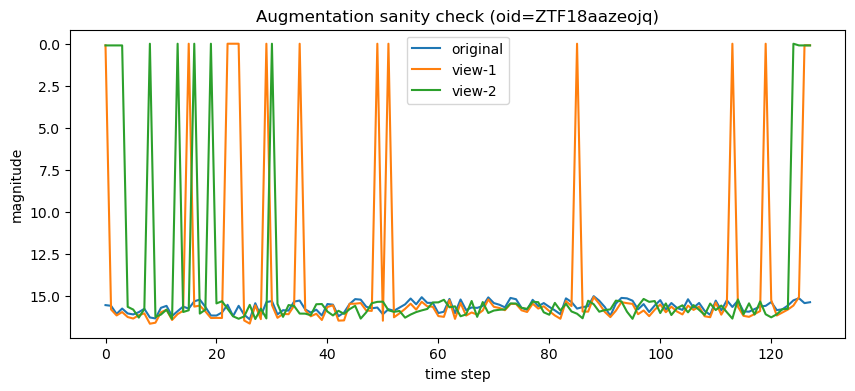

Saved pairs to: outputs\light_curve_pairs.npz


In [4]:
# -------------------------
# 4) Quick visualization
# -------------------------
idx = int(rng.integers(0, len(X)))
x0 = X[idx]
x1 = V1[idx]
x2 = V2[idx]

mag0 = x0[:, 0]
mag1 = x1[:, 0]
mag2 = x2[:, 0]

plt.figure(figsize=(10, 4))
plt.plot(mag0, label="original")
plt.plot(mag1, label="view-1")
plt.plot(mag2, label="view-2")
plt.gca().invert_yaxis()  # magnitudes: brighter is smaller
plt.title(f"Augmentation sanity check (oid={oid[idx]})")
plt.xlabel("time step")
plt.ylabel("magnitude")
plt.legend()
plt.show()

# -------------------------
# 5) Export augmented pairs
# -------------------------
np.savez_compressed(
    OUT_PAIRS,
    oid=np.array(oid, dtype=object),
    X1=V1.astype(np.float32),
    X2=V2.astype(np.float32),
    feature_names=np.array(feature_names, dtype=object),
)
print("Saved pairs to:", OUT_PAIRS)
